# Predictive Modeling Using Machine Learning

## Online Retail Transaction Prediction

This project extends the Online Retail Data Cleaning and Visualization project by applying supervised machine learning techniques.

The objective is to build classification models that predict whether a transaction is a high-value transaction based on available transaction information.

### Machine Learning Algorithms
- Decision Tree Classifier
- Random Forest Classifier

### Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix
- ROC Curve and AUC

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the cleaned dataset from Week 1

file_path = "../output/cleaned_online_retail.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 524845
Columns: 10


C:\Users\MANISHA\AppData\Local\Temp\ipykernel_13828\351868579.py:5: DtypeWarning: Columns (0: InvoiceNo) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 524845 entries, 0 to 524844
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    524845 non-null  object 
 1   StockCode    524845 non-null  str    
 2   Description  524845 non-null  str    
 3   Quantity     524845 non-null  int64  
 4   InvoiceDate  524845 non-null  str    
 5   UnitPrice    524845 non-null  float64
 6   CustomerID   392662 non-null  float64
 7   Country      524845 non-null  str    
 8   TotalSales   524845 non-null  float64
 9   Month        524845 non-null  str    
dtypes: float64(3), int64(1), object(1), str(5)
memory usage: 40.0+ MB
None


In [5]:
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132183
Country             0
TotalSales          0
Month               0
dtype: int64


In [6]:
# Calculate the median transaction value

median_sales = df["TotalSales"].median()

print("Median transaction sales:", median_sales)

Median transaction sales: 8.45


In [7]:
# Create binary target variable

df["HighValue"] = np.where(
    df["TotalSales"] >= median_sales,
    1,
    0
)

print(df["HighValue"].value_counts())

HighValue
1    280027
0    244818
Name: count, dtype: int64


In [8]:
print(df["HighValue"].value_counts())

HighValue
1    280027
0    244818
Name: count, dtype: int64


In [9]:
# Select features and target

features = ["Quantity", "UnitPrice", "Country", "Month"]

X = df[features].copy()
y = df["HighValue"].copy()

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Quantity  UnitPrice         Country    Month
0         6       2.55  United Kingdom  2010-12
1         6       3.39  United Kingdom  2010-12
2         8       2.75  United Kingdom  2010-12
3         6       3.39  United Kingdom  2010-12
4         6       3.39  United Kingdom  2010-12

Target:
0    1
1    1
2    1
3    1
4    1
Name: HighValue, dtype: int64


In [10]:
# Convert categorical variables into numerical variables

X = pd.get_dummies(
    X,
    columns=["Country", "Month"],
    drop_first=True
)

print("Number of features after encoding:", X.shape[1])
print(X.head())

Number of features after encoding: 51
   Quantity  UnitPrice  Country_Austria  Country_Bahrain  Country_Belgium  \
0         6       2.55            False            False            False   
1         6       3.39            False            False            False   
2         8       2.75            False            False            False   
3         6       3.39            False            False            False   
4         6       3.39            False            False            False   

   Country_Brazil  Country_Canada  Country_Channel Islands  Country_Cyprus  \
0           False           False                    False           False   
1           False           False                    False           False   
2           False           False                    False           False   
3           False           False                    False           False   
4           False           False                    False           False   

   Country_Czech Republic  ...

In [11]:
# Convert boolean columns to integers

X = X.astype(int)

print(X.dtypes.head())

Quantity           int64
UnitPrice          int64
Country_Austria    int64
Country_Bahrain    int64
Country_Belgium    int64
dtype: object


In [12]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (419876, 51)
Testing data: (104969, 51)


In [13]:
# Train Decision Tree model

decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

decision_tree.fit(X_train, y_train)

# Make predictions
y_pred_dt = decision_tree.predict(X_test)

print("Decision Tree training completed!")

Decision Tree training completed!


In [14]:
# Evaluate Decision Tree

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print("Decision Tree Performance")
print("-------------------------")
print("Accuracy :", round(dt_accuracy, 4))
print("Precision:", round(dt_precision, 4))
print("Recall   :", round(dt_recall, 4))
print("F1 Score :", round(dt_f1, 4))

Decision Tree Performance
-------------------------
Accuracy : 0.9376
Precision: 0.9214
Recall   : 0.9654
F1 Score : 0.9429


In [15]:
# Detailed classification report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.96      0.91      0.93     48964
           1       0.92      0.97      0.94     56005

    accuracy                           0.94    104969
   macro avg       0.94      0.94      0.94    104969
weighted avg       0.94      0.94      0.94    104969



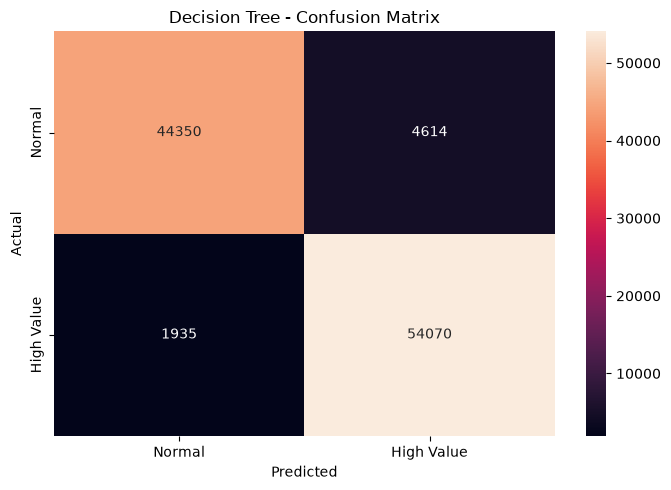

In [16]:
# Decision Tree confusion matrix

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    xticklabels=["Normal", "High Value"],
    yticklabels=["Normal", "High Value"]
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig("../visualizations/decision_tree_confusion_matrix.png")
plt.show()

In [17]:
# Train Random Forest model

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

# Make predictions
y_pred_rf = random_forest.predict(X_test)

print("Random Forest training completed!")

Random Forest training completed!


In [18]:
# Evaluate Random Forest

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-------------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))

Random Forest Performance
-------------------------
Accuracy : 0.9192
Precision: 0.8882
Recall   : 0.9707
F1 Score : 0.9276


In [19]:
# Detailed classification report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.96      0.86      0.91     48964
           1       0.89      0.97      0.93     56005

    accuracy                           0.92    104969
   macro avg       0.93      0.92      0.92    104969
weighted avg       0.92      0.92      0.92    104969



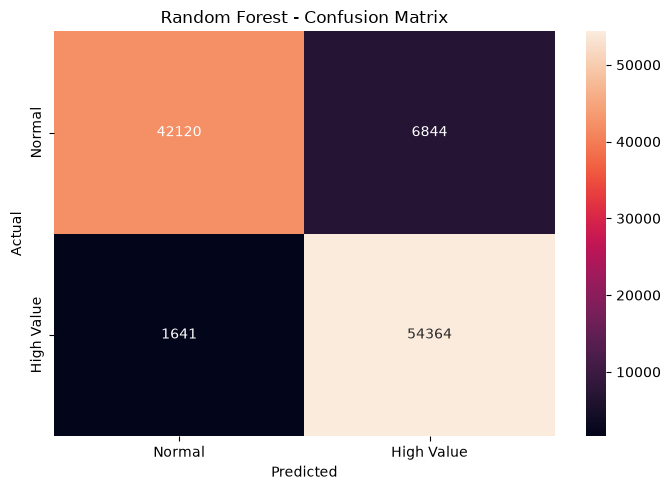

In [20]:
# Random Forest confusion matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=["Normal", "High Value"],
    yticklabels=["Normal", "High Value"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig("../visualizations/random_forest_confusion_matrix.png")
plt.show()

In [21]:
# Compare model performance

model_comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_accuracy, rf_accuracy],
    "Precision": [dt_precision, rf_precision],
    "Recall": [dt_recall, rf_recall],
    "F1 Score": [dt_f1, rf_f1]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.937610,0.921376,0.965450,0.942898
1,Random Forest,0.919167,0.888185,0.970699,0.927610


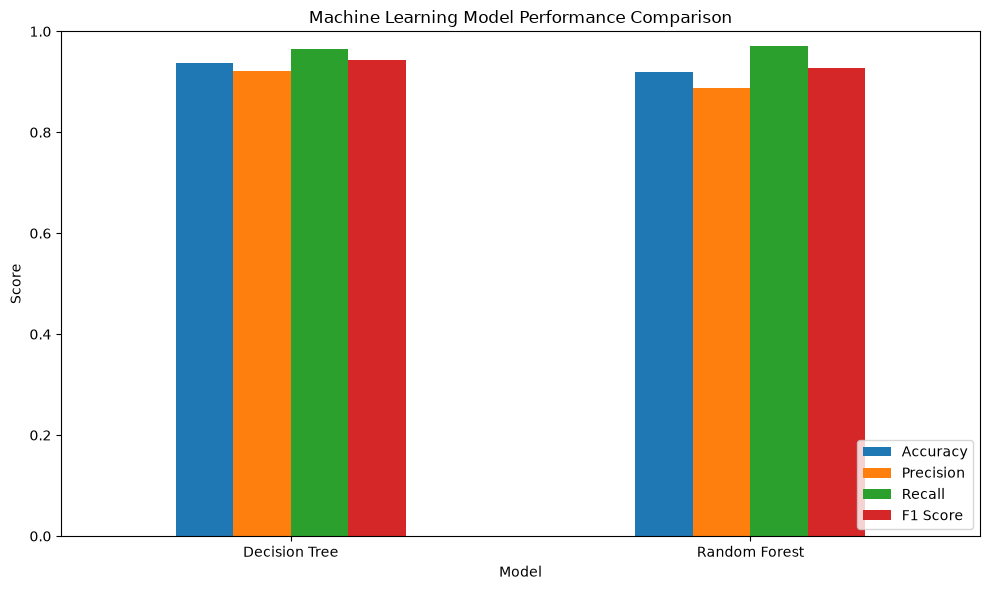

In [22]:
# Visualize model performance

model_comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.tight_layout()
plt.savefig("../visualizations/model_comparison.png")
plt.show()

In [23]:
# Calculate prediction probabilities

y_prob_dt = decision_tree.predict_proba(X_test)[:, 1]
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

# Calculate ROC curves

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# Calculate AUC

auc_dt = roc_auc_score(y_test, y_prob_dt)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Decision Tree AUC:", round(auc_dt, 4))
print("Random Forest AUC:", round(auc_rf, 4))

Decision Tree AUC: 0.9888
Random Forest AUC: 0.9754


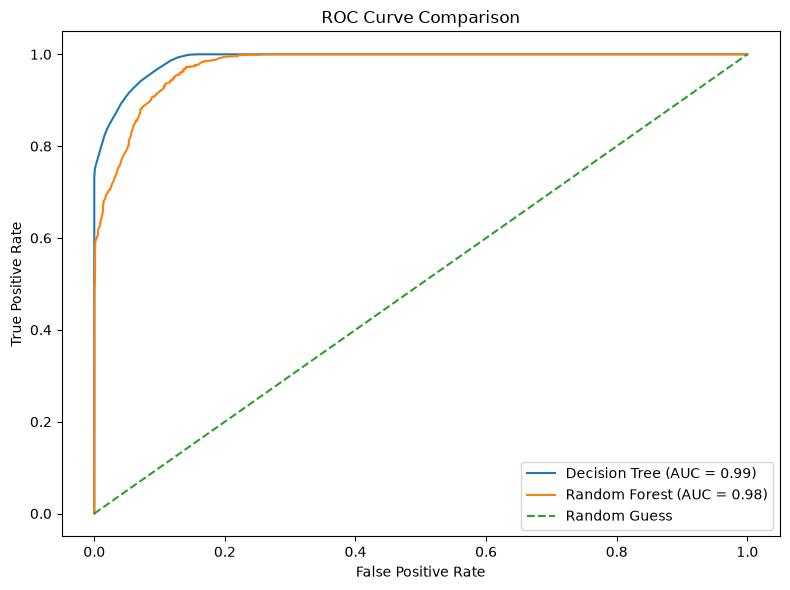

In [24]:
# Plot ROC curves

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree (AUC = {auc_dt:.2f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.savefig("../visualizations/roc_curve_comparison.png")
plt.show()

In [25]:
# Decision Tree feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": decision_tree.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

print(feature_importance)

                   Feature  Importance
0                 Quantity    0.551439
1                UnitPrice    0.444327
37  Country_United Kingdom    0.001151
49           Month_2011-11    0.000610
48           Month_2011-10    0.000561
50           Month_2011-12    0.000303
47           Month_2011-09    0.000262
25     Country_Netherlands    0.000201
11            Country_EIRE    0.000147
45           Month_2011-07    0.000146


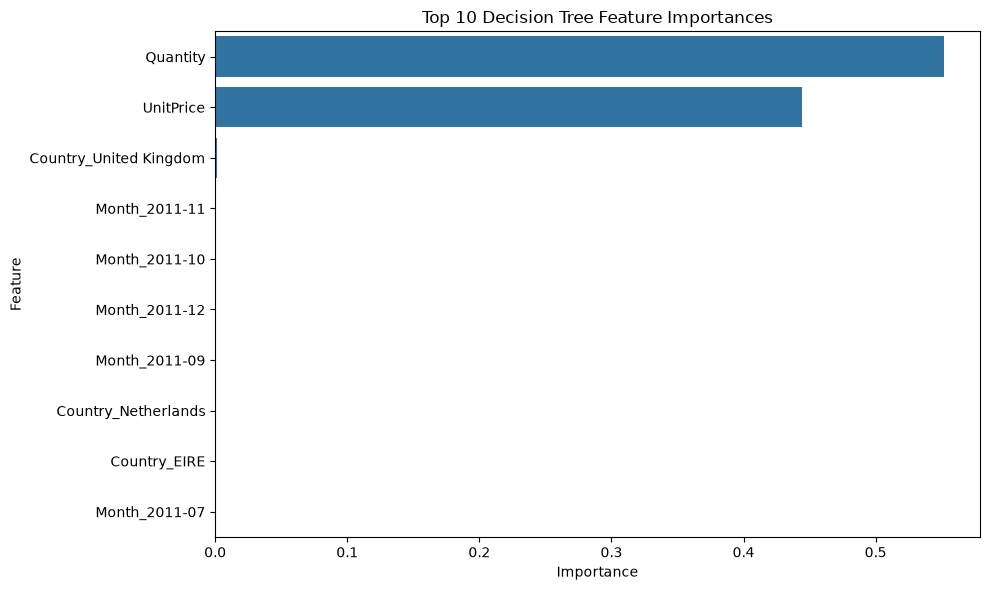

In [26]:
# Visualize feature importance

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Decision Tree Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig("../visualizations/feature_importance.png")
plt.show()

## 10. Model Findings

### Model Performance

Two supervised machine learning algorithms were evaluated:

- Decision Tree Classifier
- Random Forest Classifier

The Decision Tree achieved an accuracy of approximately 94% and an AUC of 0.99.

The Random Forest achieved an accuracy of approximately 92% and an AUC of 0.98.

Based on the evaluation results, the Decision Tree performed slightly better than the Random Forest for this dataset.

### Important Features

The Decision Tree feature-importance analysis showed that Quantity and UnitPrice were the most influential features.

Quantity had the highest feature importance, followed by UnitPrice. Country and Month contributed relatively little to the model's predictions.

## 11. Conclusion

This project extended the Online Retail Data Cleaning and Visualization project by applying supervised machine learning techniques.

A binary target variable, HighValue, was created to classify transactions into normal-value and high-value transactions. The dataset was divided into training and testing sets using an 80:20 ratio.

Decision Tree and Random Forest classifiers were trained and evaluated using accuracy, precision, recall, F1-score, confusion matrices, and ROC-AUC.

The Decision Tree achieved better overall performance than the Random Forest in this experiment, with approximately 94% accuracy and an AUC of 0.99.

The ROC curves and confusion matrices demonstrate that both models were able to distinguish between the two transaction classes effectively.

### Limitation

The HighValue target was derived from TotalSales, which itself is calculated using Quantity and UnitPrice. Therefore, Quantity and UnitPrice naturally have strong predictive power. This project is intended primarily to demonstrate the machine learning workflow, model training, and evaluation process rather than to represent a real-world future-sales prediction system.